In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

RANDOM_STATE = 42

In [36]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [37]:
df.shape

(41188, 21)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [39]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [40]:
# target distribution
print(df["y"].value_counts())
print("Percentage distribution:")
print(df["y"].value_counts(normalize=True) * 100)

no     36548
yes     4640
Name: y, dtype: int64
Percentage distribution:
no     88.734583
yes    11.265417
Name: y, dtype: float64


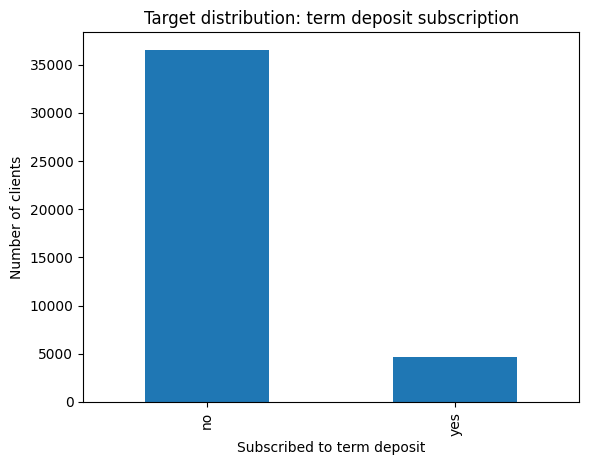

In [41]:
df["y"].value_counts().plot(kind="bar")
plt.title("Target distribution: term deposit subscription")
plt.xlabel("Subscribed to term deposit")
plt.ylabel("Number of clients")
plt.show()

In [42]:
# unknown values in each column
unknown_counts = (df == "unknown").sum().sort_values(ascending=False)
unknown_counts[unknown_counts > 0]

default      8597
education    1731
housing       990
loan          990
job           330
marital        80
dtype: int64

In [43]:
# categorical columns
categorical_cols = df.select_dtypes(include="object").columns.tolist()
categorical_cols.remove("y")

for col in categorical_cols:
    print("", col)
    print(df[col].value_counts().head(10))

 job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
Name: job, dtype: int64
 marital
married     24928
single      11568
divorced     4612
unknown        80
Name: marital, dtype: int64
 education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: education, dtype: int64
 default
no         32588
unknown     8597
yes            3
Name: default, dtype: int64
 housing
yes        21576
no         18622
unknown      990
Name: housing, dtype: int64
 loan
no         33950
yes         6248
unknown      990
Name: loan, dtype: int64
 contact
cellular     26144
telephone    15044
Name: contact, dtype: int64
 month
may    13769
jul   

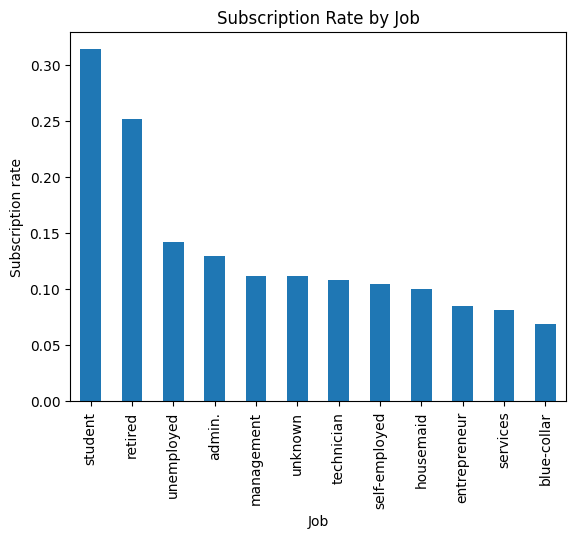

In [44]:
job_rates = df.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)
job_rates.plot(kind="bar")
plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription rate")
plt.show()

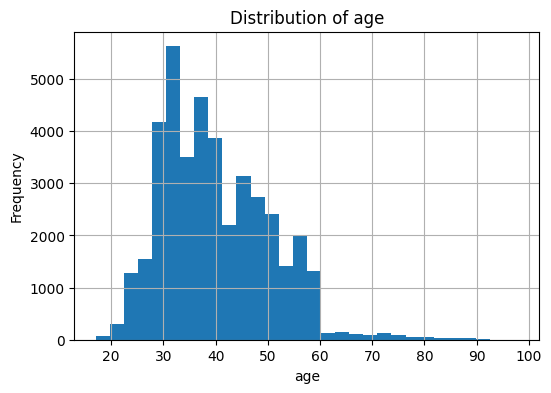

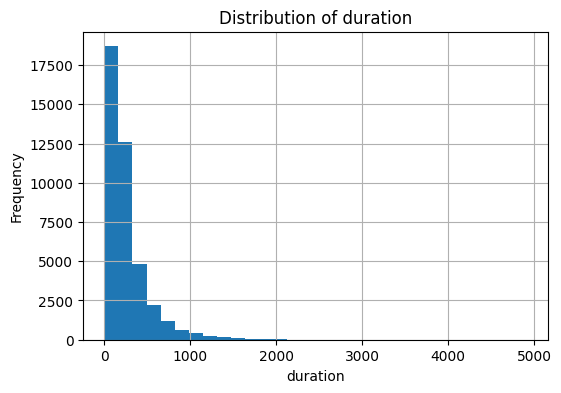

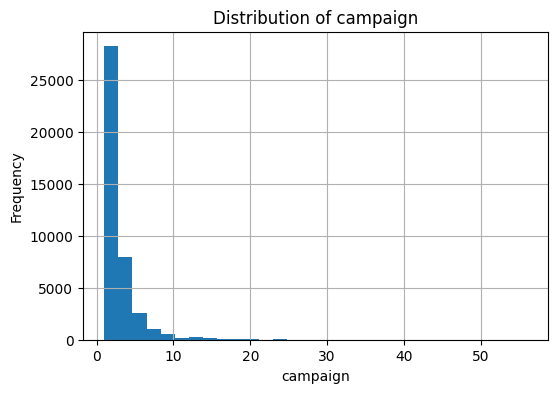

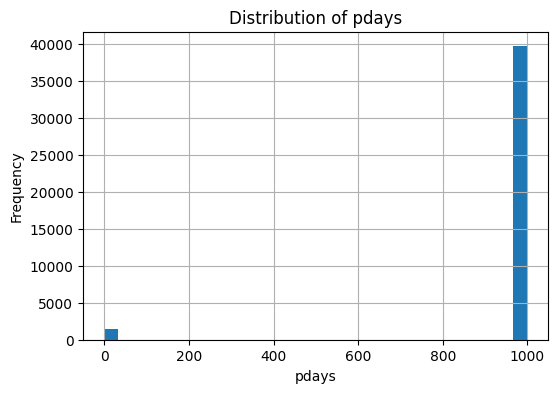

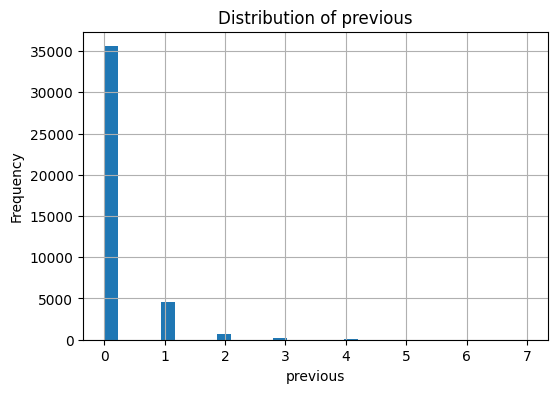

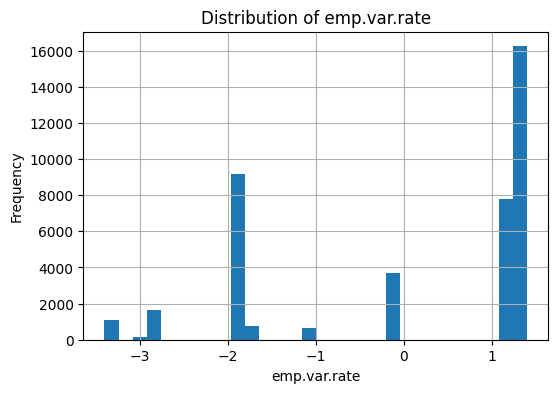

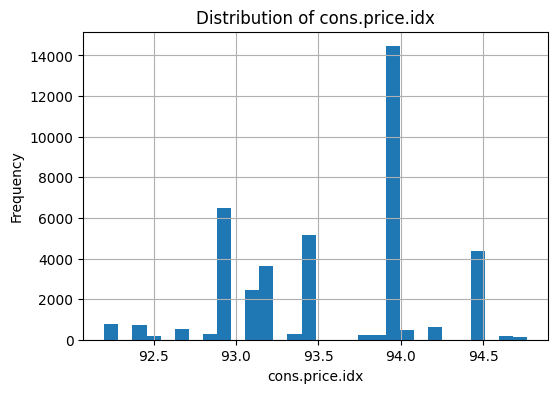

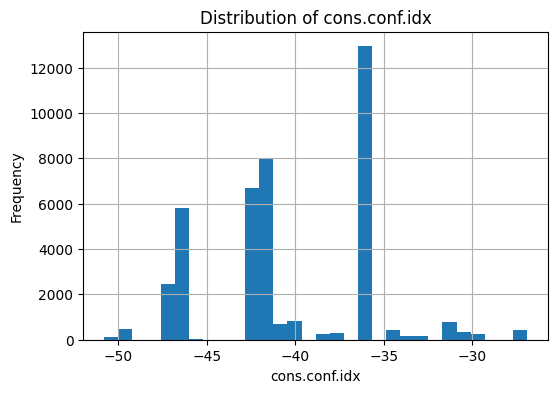

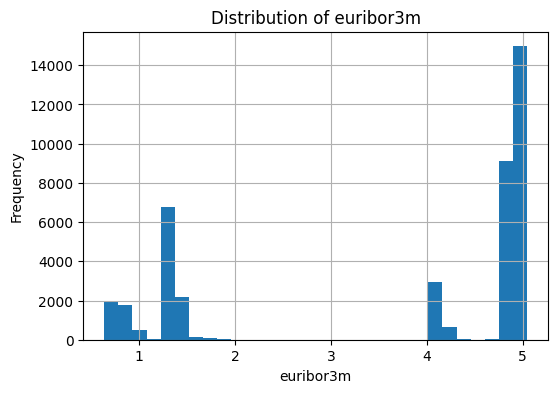

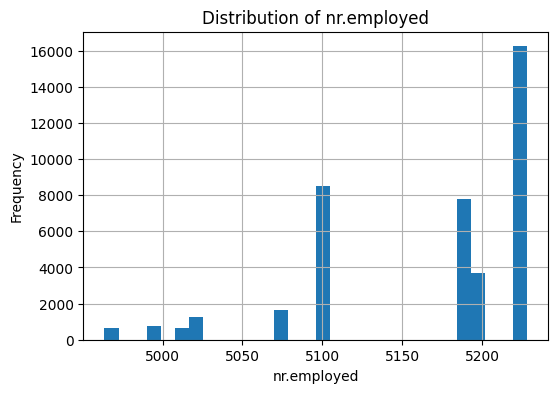

In [45]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    df[col].hist(bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [46]:
def prepare_data(data, include_duration=True):
    """Prepare the bank marketing data for machine learning."""
    df_clean = data.copy()

    # replace unknown as missing values
    df_clean = df_clean.replace("unknown", np.nan)

    if not include_duration and "duration" in df_clean.columns:
        df_clean = df_clean.drop(columns=["duration"])

    # Convert target to numeric: yes = 1, no = 0
    df_clean["y"] = df_clean["y"].map({"no": 0, "yes": 1})

    cat_cols = df_clean.select_dtypes(include="object").columns.tolist()
    num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
    num_cols.remove("y")

    # missing categorical values with mode imputation 
    for col in cat_cols:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)

    # missing numerical values with median
    for col in num_cols:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

    X = df_clean.drop(columns=["y"])
    y = df_clean["y"]

    # categorical variables into dummy variables
    X = pd.get_dummies(X, drop_first=True)

    return X, y

In [47]:
def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Print common classification metrics and confusion matrix."""
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{model_name} Results")
    print("-" * 40)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1}

In [48]:
X_duration, y_duration = prepare_data(df, include_duration=True)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_duration, y_duration,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_duration
)

print(X_train_d.shape, X_test_d.shape)

(30891, 47) (10297, 47)


In [49]:
scaler_d = StandardScaler()
X_train_d_scaled = scaler_d.fit_transform(X_train_d)
X_test_d_scaled = scaler_d.transform(X_test_d)

log_reg_d = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg_d.fit(X_train_d_scaled, y_train_d)

results = []
results.append(evaluate_model(log_reg_d, X_test_d_scaled, y_test_d, "Logistic Regression with duration"))

Logistic Regression with duration Results
----------------------------------------
Accuracy : 0.8643
Precision: 0.4495
Recall   : 0.9086
F1-score : 0.6014
Confusion Matrix:
[[7846 1291]
 [ 106 1054]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      9137
           1       0.45      0.91      0.60      1160

    accuracy                           0.86     10297
   macro avg       0.72      0.88      0.76     10297
weighted avg       0.93      0.86      0.88     10297



In [50]:
tree_d = DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE)
tree_d.fit(X_train_d, y_train_d)

results.append(evaluate_model(tree_d, X_test_d, y_test_d, "Decision Tree with duration"))

Decision Tree with duration Results
----------------------------------------
Accuracy : 0.8555
Precision: 0.4319
Recall   : 0.8966
F1-score : 0.5830
Confusion Matrix:
[[7769 1368]
 [ 120 1040]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      9137
           1       0.43      0.90      0.58      1160

    accuracy                           0.86     10297
   macro avg       0.71      0.87      0.75     10297
weighted avg       0.92      0.86      0.88     10297



In [51]:
rf_experiments = []

n_estimators_options = [100, 200, 300]
max_depth_options = [8, 12, 16, None]

best_oob = -1
best_params = None
best_rf_d = None

for n_estimators in n_estimators_options:
    for max_depth in max_depth_options:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            oob_score=True,
            bootstrap=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_train_d, y_train_d)
        oob = rf.oob_score_
        rf_experiments.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "oob_score": oob
        })
        print(f"n_estimators={n_estimators}, max_depth={max_depth}, OOB={oob:.4f}")

        if oob > best_oob:
            best_oob = oob
            best_params = {"n_estimators": n_estimators, "max_depth": max_depth}
            best_rf_d = rf

print("Best parameters:", best_params)
print("Best OOB score:", best_oob)

n_estimators=100, max_depth=8, OOB=0.8443
n_estimators=100, max_depth=12, OOB=0.8771
n_estimators=100, max_depth=16, OOB=0.9000
n_estimators=100, max_depth=None, OOB=0.9103
n_estimators=200, max_depth=8, OOB=0.8438
n_estimators=200, max_depth=12, OOB=0.8776
n_estimators=200, max_depth=16, OOB=0.9000
n_estimators=200, max_depth=None, OOB=0.9101
n_estimators=300, max_depth=8, OOB=0.8448
n_estimators=300, max_depth=12, OOB=0.8768
n_estimators=300, max_depth=16, OOB=0.9010
n_estimators=300, max_depth=None, OOB=0.9111
Best parameters: {'n_estimators': 300, 'max_depth': None}
Best OOB score: 0.9111067948593441


In [52]:
rf_oob_df = pd.DataFrame(rf_experiments)
rf_oob_df

,n_estimators,max_depth,oob_score
0,100,8.0,0.844291
1,100,12.0,0.877052
2,100,16.0,0.899971
3,100,NaN,0.910265
4,200,8.0,0.843806
5,200,12.0,0.877602
6,200,16.0,0.900003
7,200,NaN,0.910103
8,300,8.0,0.844842
9,300,12.0,0.876825


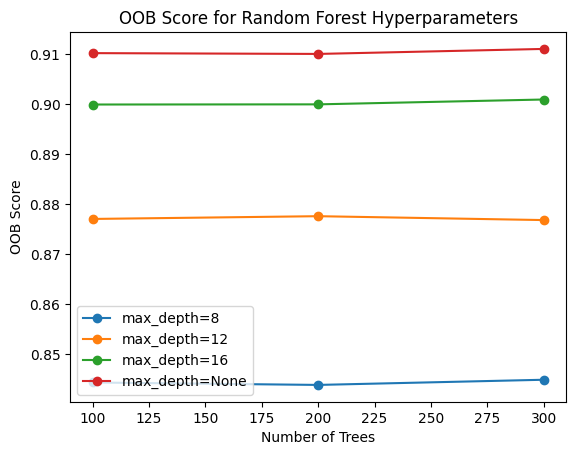

In [53]:
for depth in max_depth_options:

    if depth is None:
        subset = rf_oob_df[rf_oob_df["max_depth"].isna()]
        label = "max_depth=None"
    else:
        subset = rf_oob_df[rf_oob_df["max_depth"] == depth]
        label = f"max_depth={depth}"

    plt.plot(
        subset["n_estimators"],
        subset["oob_score"],
        marker="o",
        label=label
    )

plt.title("OOB Score for Random Forest Hyperparameters")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Score")
plt.legend()
plt.show()

In [54]:
results.append(evaluate_model(best_rf_d, X_test_d, y_test_d, "Random Forest with duration"))

Random Forest with duration Results
----------------------------------------
Accuracy : 0.9133
Precision: 0.6949
Recall   : 0.4103
F1-score : 0.5160
Confusion Matrix:
[[8928  209]
 [ 684  476]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      9137
           1       0.69      0.41      0.52      1160

    accuracy                           0.91     10297
   macro avg       0.81      0.69      0.73     10297
weighted avg       0.90      0.91      0.90     10297



In [55]:
feature_importance_d = pd.DataFrame({
    "feature": X_train_d.columns,
    "importance": best_rf_d.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_d.head(15)

,feature,importance
1,duration,0.383101
8,euribor3m,0.097302
9,nr.employed,0.071098
0,age,0.064331
5,emp.var.rate,0.044456
2,campaign,0.032959
7,cons.conf.idx,0.032820
6,cons.price.idx,0.022814
3,pdays,0.021283
29,housing_yes,0.013884


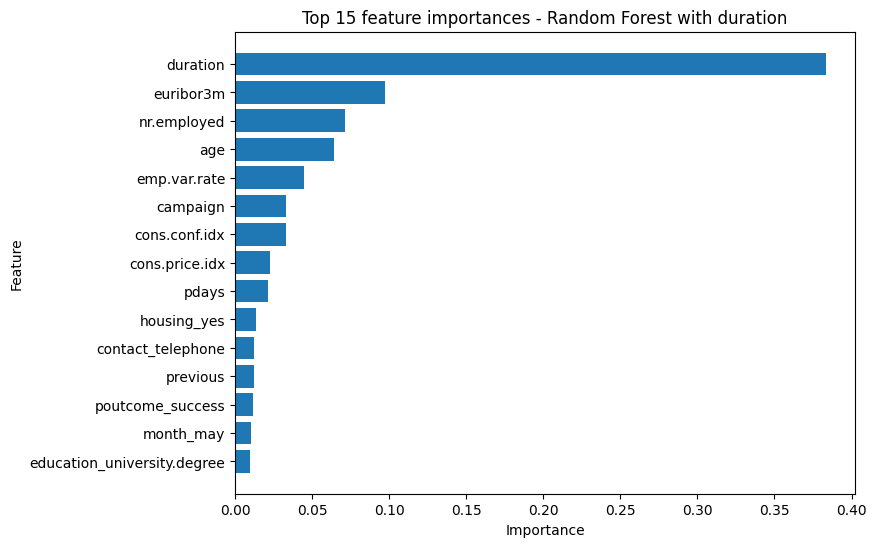

In [56]:
top_features = feature_importance_d.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 feature importances - Random Forest with duration")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [57]:
X_no_duration, y_no_duration = prepare_data(df, include_duration=False)

X_train_nd, X_test_nd, y_train_nd, y_test_nd = train_test_split(
    X_no_duration, y_no_duration,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_no_duration
)

print(X_train_nd.shape, X_test_nd.shape)

(30891, 46) (10297, 46)


In [58]:
scaler_nd = StandardScaler()
X_train_nd_scaled = scaler_nd.fit_transform(X_train_nd)
X_test_nd_scaled = scaler_nd.transform(X_test_nd)

log_reg_nd = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg_nd.fit(X_train_nd_scaled, y_train_nd)

results.append(evaluate_model(log_reg_nd, X_test_nd_scaled, y_test_nd, "Logistic Regression without duration"))

Logistic Regression without duration Results
----------------------------------------
Accuracy : 0.8342
Precision: 0.3659
Recall   : 0.6431
F1-score : 0.4664
Confusion Matrix:
[[7844 1293]
 [ 414  746]]
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90      9137
           1       0.37      0.64      0.47      1160

    accuracy                           0.83     10297
   macro avg       0.66      0.75      0.68     10297
weighted avg       0.88      0.83      0.85     10297



In [59]:
rf_experiments_nd = []

best_oob_nd = -1
best_params_nd = None
best_rf_nd = None

for n_estimators in n_estimators_options:
    for max_depth in max_depth_options:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            oob_score=True,
            bootstrap=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
        rf.fit(X_train_nd, y_train_nd)
        oob = rf.oob_score_
        rf_experiments_nd.append({
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "oob_score": oob
        })
        print(f"n_estimators={n_estimators}, max_depth={max_depth}, OOB={oob:.4f}")

        if oob > best_oob_nd:
            best_oob_nd = oob
            best_params_nd = {"n_estimators": n_estimators, "max_depth": max_depth}
            best_rf_nd = rf

print("Best parameters:", best_params_nd)
print("Best OOB score:", best_oob_nd)

n_estimators=100, max_depth=8, OOB=0.8433
n_estimators=100, max_depth=12, OOB=0.8626
n_estimators=100, max_depth=16, OOB=0.8795
n_estimators=100, max_depth=None, OOB=0.8905
n_estimators=200, max_depth=8, OOB=0.8432
n_estimators=200, max_depth=12, OOB=0.8631
n_estimators=200, max_depth=16, OOB=0.8797
n_estimators=200, max_depth=None, OOB=0.8911
n_estimators=300, max_depth=8, OOB=0.8437
n_estimators=300, max_depth=12, OOB=0.8633
n_estimators=300, max_depth=16, OOB=0.8802
n_estimators=300, max_depth=None, OOB=0.8907
Best parameters: {'n_estimators': 200, 'max_depth': None}
Best OOB score: 0.891133339807711


In [60]:
rf_oob_nd_df = pd.DataFrame(rf_experiments_nd)
rf_oob_nd_df

,n_estimators,max_depth,oob_score
0,100,8.0,0.843255
1,100,12.0,0.862581
2,100,16.0,0.879512
3,100,NaN,0.890454
4,200,8.0,0.843223
5,200,12.0,0.863067
6,200,16.0,0.879738
7,200,NaN,0.891133
8,300,8.0,0.843709
9,300,12.0,0.863326


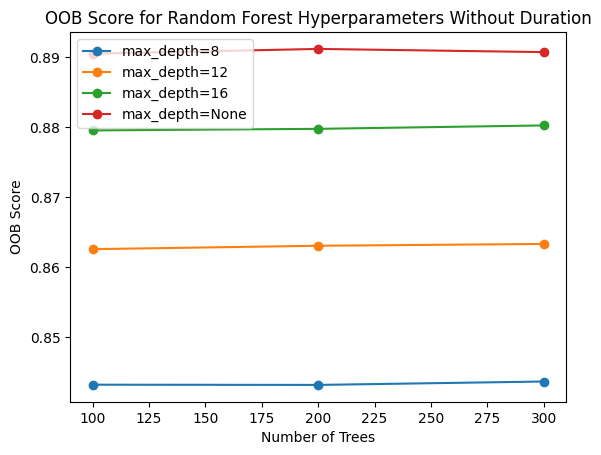

In [61]:
for depth in max_depth_options:

    if depth is None:
        subset = rf_oob_nd_df[rf_oob_nd_df["max_depth"].isna()]
        label = "max_depth=None"
    else:
        subset = rf_oob_nd_df[rf_oob_nd_df["max_depth"] == depth]
        label = f"max_depth={depth}"

    plt.plot(
        subset["n_estimators"],
        subset["oob_score"],
        marker="o",
        label=label
    )

plt.title("OOB Score for Random Forest Hyperparameters Without Duration")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Score")
plt.legend()
plt.show()

In [62]:
results.append(evaluate_model(best_rf_nd, X_test_nd, y_test_nd, "Random Forest without duration"))

Random Forest without duration Results
----------------------------------------
Accuracy : 0.8920
Precision: 0.5435
Recall   : 0.2586
F1-score : 0.3505
Confusion Matrix:
[[8885  252]
 [ 860  300]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      9137
           1       0.54      0.26      0.35      1160

    accuracy                           0.89     10297
   macro avg       0.73      0.62      0.65     10297
weighted avg       0.87      0.89      0.87     10297



In [63]:
feature_importance_nd = pd.DataFrame({
    "feature": X_train_nd.columns,
    "importance": best_rf_nd.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_nd.head(15)

,feature,importance
0,age,0.167061
7,euribor3m,0.148325
1,campaign,0.088001
8,nr.employed,0.057604
4,emp.var.rate,0.048741
28,housing_yes,0.034906
6,cons.conf.idx,0.029581
29,loan_yes,0.023172
2,pdays,0.023171
5,cons.price.idx,0.021898


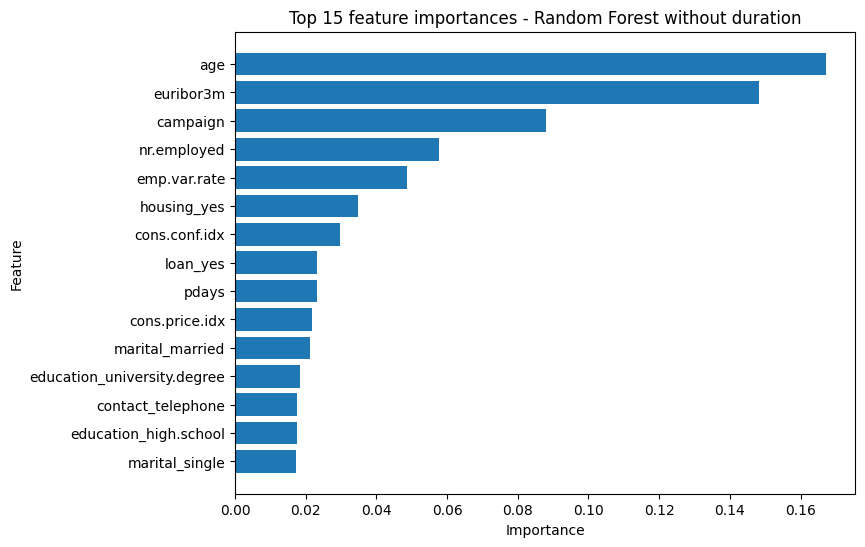

In [64]:
top_features_nd = feature_importance_nd.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_features_nd["feature"], top_features_nd["importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 feature importances - Random Forest without duration")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [65]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression with duration,0.864329,0.449467,0.908621,0.601427
1,Decision Tree with duration,0.855492,0.431894,0.896552,0.582960
2,Random Forest with duration,0.913276,0.694891,0.410345,0.515989
3,Logistic Regression without duration,0.834224,0.365866,0.643103,0.466396
4,Random Forest without duration,0.892007,0.543478,0.258621,0.350467


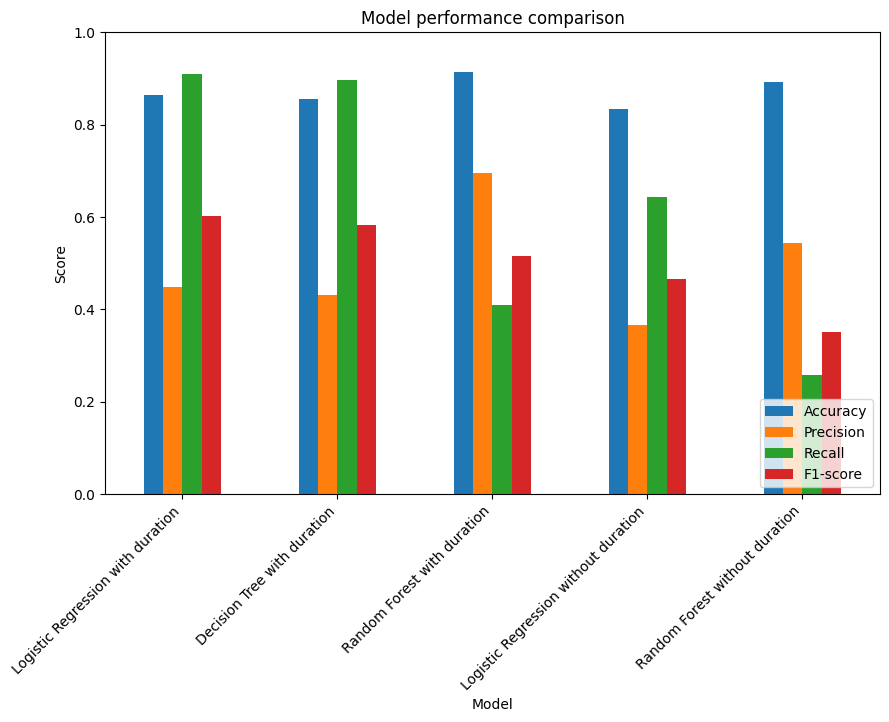

In [66]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(kind="bar", figsize=(10, 6))
plt.title("Model performance comparison")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()